# 05 Model Comparison — Selected Union vs Canonical All-in 207

## Purpose

Run an exploratory **2 × 3 controlled comparison**:

- Feature representations:
  - **Selected union** = Jsc top-20 ∪ Voc top-20 ∪ FF top-40, with duplicates removed.
  - **Canonical all-in** = the frozen 207-feature representation from the component feature-selection notebook.
- Model families:
  - Random Forest
  - XGBoost
  - MLP

## Controlled protocol

- Same PCE-aligned 3,953 samples.
- Same ten paired 80/20 held-out splits.
- Same split is used for both feature sets and all three models.
- Hyperparameter spaces, tuning budget, inner-CV design, preprocessing, and model settings are unchanged from the previous `model''.ipynb`.
- Tuning is performed separately for each model and feature set, using only the training portion of each held-out split.
- This notebook is initially an exploratory experiment. Whether both feature sets appear in the thesis depends on the paired results.

## Dependency

Run `04_component_feature_selection_JVphysics_FFallin207_stageA.ipynb` first so that
`component_feature_selection_outputs/` contains the frozen feature-list CSV files.

In [1]:
# ============================================================
# 0. Imports and unchanged model-comparison settings
# ============================================================

from pathlib import Path
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

DATA_PATH = Path("df_base.csv")
FEATURE_OUTPUT_DIR = Path("component_feature_selection_outputs")
OUTPUT_DIR = Path("model_comparison_selected_vs_allin207_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Unchanged from the previous model-comparison notebook.
HOLDOUT_SEEDS = list(range(10))
TEST_SIZE = 0.20
INNER_CV_SPLITS = 3
N_ITER_TUNE = 12

PCE_TARGET = "jv.default_PCE"
COMPONENT_TARGETS = ["jv.default_Jsc", "jv.default_Voc", "jv.default_FF"]
ALL_TARGET_COLS = COMPONENT_TARGETS + [PCE_TARGET]

EXPECTED_ALLIN_FEATURES = 207
EXPECTED_JSC_SELECTED = 20
EXPECTED_VOC_SELECTED = 20
EXPECTED_FF_SELECTED = 40

RUN_TUNED_COMPARISON = True

print("DATA_PATH:", DATA_PATH)
print("FEATURE_OUTPUT_DIR:", FEATURE_OUTPUT_DIR)
print("HOLDOUT_SEEDS:", HOLDOUT_SEEDS)
print(
    "Tuning budget per model:",
    N_ITER_TUNE,
    "parameter samples x",
    INNER_CV_SPLITS,
    "inner CV folds",
)

DATA_PATH: df_base.csv
FEATURE_OUTPUT_DIR: component_feature_selection_outputs
HOLDOUT_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Tuning budget per model: 12 parameter samples x 3 inner CV folds


In [2]:
# ============================================================
# 1. Load df_base and recreate the two approved Level-3 features
# ============================================================

def resolve_path(path):
    path = Path(path)
    candidates = [
        path,
        Path.cwd() / path,
        Path.cwd().parent / path,
        Path("/mnt/data") / path.name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {path}. Place it beside this notebook or update the path."
    )

DATA_PATH = resolve_path(DATA_PATH)
df_base = pd.read_csv(DATA_PATH, low_memory=False)

NUMERIC_SOURCE_COLS = [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "jv.default_Jsc",
    "jv.default_Voc",
    "jv.default_FF",
    "jv.default_PCE",
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

for col in NUMERIC_SOURCE_COLS:
    if col in df_base.columns:
        df_base[col] = pd.to_numeric(df_base[col], errors="coerce")


def num_col(frame, column):
    return pd.to_numeric(frame[column], errors="coerce")


def safe_divide(numerator, denominator):
    return (numerator / denominator.replace(0, np.nan)).replace(
        [np.inf, -np.inf], np.nan
    )


def add_approved_level3_features(frame):
    frame = frame.copy()
    required = {
        "PVK_thickness_clean",
        "ETL_thickness_clean",
        "HTL_thickness_clean",
        "BC_thickness_clean",
    }
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise KeyError(f"Cannot build Level-3 features; missing: {missing}")

    pvk = num_col(frame, "PVK_thickness_clean")
    etl = num_col(frame, "ETL_thickness_clean")
    htl = num_col(frame, "HTL_thickness_clean")
    bc = num_col(frame, "BC_thickness_clean")

    frame["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
    frame["ff_PVK_fraction_of_total_stack"] = safe_divide(
        pvk, pvk + etl + htl + bc
    )
    return frame


df_base = add_approved_level3_features(df_base).replace(
    [np.inf, -np.inf], np.nan
)

missing_targets = [col for col in ALL_TARGET_COLS if col not in df_base.columns]
if missing_targets:
    raise KeyError(f"df_base is missing targets: {missing_targets}")

Y_all = df_base[ALL_TARGET_COLS].apply(pd.to_numeric, errors="coerce")
common_target_mask = Y_all[ALL_TARGET_COLS].notna().all(axis=1)

X_source = (
    df_base.loc[common_target_mask]
    .replace({pd.NA: np.nan})
    .reset_index(drop=True)
)
y_pce = (
    Y_all.loc[common_target_mask, PCE_TARGET]
    .reset_index(drop=True)
)

print("Loaded:", DATA_PATH)
print("df_base rows:", len(df_base))
print("PCE-aligned rows:", len(X_source))

Loaded: df_base.csv
df_base rows: 3953
PCE-aligned rows: 3953


## Feature definitions

The feature lists are **not hard-coded here**. They are loaded from the frozen outputs of the component feature-selection notebook, so tomorrow's corrected FF run can flow into this comparison without manually copying columns.

In [3]:
# ============================================================
# 2. Load frozen selected features and canonical all-in 207
# ============================================================

def resolve_feature_output_dir(path):
    path = Path(path)
    candidates = [
        path,
        Path.cwd() / path,
        Path.cwd().parent / path,
        Path("/mnt/data") / path.name,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find feature-output directory: {path}\n"
        "Run the component feature-selection notebook first."
    )


def read_feature_csv(path, preferred_column):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing feature-list file: {path}\n"
            "Run the component feature-selection notebook first."
        )

    table = pd.read_csv(path)
    if preferred_column in table.columns:
        values = table[preferred_column]
    elif table.shape[1] == 1:
        values = table.iloc[:, 0]
    else:
        raise ValueError(
            f"{path.name} does not contain '{preferred_column}' "
            "and is not a one-column CSV."
        )

    features = [
        str(value).strip()
        for value in values.dropna().tolist()
        if str(value).strip()
    ]
    return list(dict.fromkeys(features))


FEATURE_OUTPUT_DIR = resolve_feature_output_dir(FEATURE_OUTPUT_DIR)

ALLIN_FEATURES = read_feature_csv(
    FEATURE_OUTPUT_DIR / "allin_feature_list.csv",
    "allin_feature",
)
JSC_SELECTED_FEATURES = read_feature_csv(
    FEATURE_OUTPUT_DIR / "jsc_selected_top20.csv",
    "selected_feature",
)
VOC_SELECTED_FEATURES = read_feature_csv(
    FEATURE_OUTPUT_DIR / "voc_selected_top20.csv",
    "selected_feature",
)
FF_SELECTED_FEATURES = read_feature_csv(
    FEATURE_OUTPUT_DIR / "ff_selected_top40.csv",
    "selected_feature",
)

SELECTED_UNION_FEATURES = list(dict.fromkeys(
    JSC_SELECTED_FEATURES
    + VOC_SELECTED_FEATURES
    + FF_SELECTED_FEATURES
))

assert len(ALLIN_FEATURES) == EXPECTED_ALLIN_FEATURES, (
    f"Expected {EXPECTED_ALLIN_FEATURES} all-in features, "
    f"found {len(ALLIN_FEATURES)}."
)
assert len(JSC_SELECTED_FEATURES) == EXPECTED_JSC_SELECTED, (
    f"Expected {EXPECTED_JSC_SELECTED} Jsc selected features, "
    f"found {len(JSC_SELECTED_FEATURES)}."
)
assert len(VOC_SELECTED_FEATURES) == EXPECTED_VOC_SELECTED, (
    f"Expected {EXPECTED_VOC_SELECTED} Voc selected features, "
    f"found {len(VOC_SELECTED_FEATURES)}."
)
assert len(FF_SELECTED_FEATURES) == EXPECTED_FF_SELECTED, (
    f"Expected {EXPECTED_FF_SELECTED} FF selected features, "
    f"found {len(FF_SELECTED_FEATURES)}."
)

required_features = set(ALLIN_FEATURES) | set(SELECTED_UNION_FEATURES)
missing_from_data = sorted(required_features.difference(X_source.columns))
if missing_from_data:
    raise KeyError(
        "Frozen feature lists contain columns missing from df_base: "
        + ", ".join(missing_from_data)
    )

if not set(SELECTED_UNION_FEATURES).issubset(set(ALLIN_FEATURES)):
    selected_outside_allin = sorted(
        set(SELECTED_UNION_FEATURES).difference(ALLIN_FEATURES)
    )
    raise ValueError(
        "Selected union is expected to be a subset of canonical all-in. "
        f"Outside all-in: {selected_outside_allin}"
    )

X_selected = X_source[SELECTED_UNION_FEATURES].copy()
X_allin = X_source[ALLIN_FEATURES].copy()

FEATURE_SETS = {
    "Selected union": X_selected,
    "All-in 207": X_allin,
}

feature_set_audit = pd.DataFrame([
    {
        "feature_set": name,
        "n_raw_features": frame.shape[1],
        "n_numeric": len(frame.select_dtypes(include=np.number).columns),
        "n_categorical": (
            frame.shape[1]
            - len(frame.select_dtypes(include=np.number).columns)
        ),
        "mean_missing_pct": frame.isna().mean().mean() * 100,
    }
    for name, frame in FEATURE_SETS.items()
])

component_set_audit = pd.DataFrame({
    "feature_block": [
        "Jsc selected",
        "Voc selected",
        "FF selected",
        "Selected union",
        "Canonical all-in",
    ],
    "n_features": [
        len(JSC_SELECTED_FEATURES),
        len(VOC_SELECTED_FEATURES),
        len(FF_SELECTED_FEATURES),
        len(SELECTED_UNION_FEATURES),
        len(ALLIN_FEATURES),
    ],
})

display(component_set_audit)
display(feature_set_audit.round(3))

pd.Series(
    SELECTED_UNION_FEATURES,
    name="selected_union_feature",
).to_csv(
    OUTPUT_DIR / "selected_union_feature_list.csv",
    index=False,
)
feature_set_audit.to_csv(
    OUTPUT_DIR / "feature_set_audit.csv",
    index=False,
)

,feature_block,n_features
0,Jsc selected,20
1,Voc selected,20
2,FF selected,40
3,Selected union,47
4,Canonical all-in,207


,feature_set,n_raw_features,n_numeric,n_categorical,mean_missing_pct
0,Selected union,47,11,36,2.906
1,All-in 207,207,20,187,4.514


In [4]:
# ============================================================
# 3. Unchanged preprocessing and model helpers
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(X, scale_numeric=False):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [col for col in X.columns if col not in num_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="mean"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "to_string",
            FunctionTransformer(lambda x: x.astype(str), validate=False),
        ),
        ("onehot", make_onehot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ])


def make_rf_pipeline(X, random_state):
    return Pipeline([
        ("prep", make_preprocessor(X, scale_numeric=False)),
        (
            "model",
            RandomForestRegressor(
                random_state=random_state,
                n_jobs=-1,
            ),
        ),
    ])


def make_xgb_pipeline(X, random_state):
    return Pipeline([
        ("prep", make_preprocessor(X, scale_numeric=False)),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=random_state,
                n_jobs=-1,
                tree_method="hist",
            ),
        ),
    ])


def make_mlp_pipeline(X, random_state):
    mlp = MLPRegressor(
        activation="relu",
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        max_iter=500,
        random_state=random_state,
    )

    return Pipeline([
        ("prep", make_preprocessor(X, scale_numeric=True)),
        (
            "model",
            TransformedTargetRegressor(
                regressor=mlp,
                transformer=StandardScaler(),
            ),
        ),
    ])


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def count_encoded_features_after_fit(pipeline):
    prep = pipeline.named_steps["prep"]
    num_cols = prep.transformers_[0][2]
    cat_cols = prep.transformers_[1][2]

    n_num = len(num_cols)
    if len(cat_cols) == 0:
        return int(n_num)

    onehot = prep.named_transformers_["cat"].named_steps["onehot"]
    n_cat = int(sum(len(categories) for categories in onehot.categories_))
    return int(n_num + n_cat)

## Unchanged tuned comparison

The following search spaces and tuning protocol are copied from the previous model-comparison notebook. Only the input feature representation changes.

In [5]:
# ============================================================
# 4. Unchanged hyperparameter search spaces
# ============================================================

RF_PARAM_DISTRIBUTIONS = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 12, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8, None],
}

XGB_PARAM_DISTRIBUTIONS = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__subsample": [0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.75, 0.9, 1.0],
    "model__reg_lambda": [1.0, 3.0, 5.0, 10.0],
    "model__reg_alpha": [0.0, 0.1, 1.0],
}

MLP_PARAM_DISTRIBUTIONS = {
    "model__regressor__hidden_layer_sizes": [
        (64,),
        (128,),
        (128, 64),
        (256, 128),
    ],
    "model__regressor__alpha": [1e-4, 1e-3, 1e-2],
    "model__regressor__learning_rate_init": [5e-4, 1e-3, 2e-3],
    "model__regressor__batch_size": [32, 64, 128],
}


def make_search(base_model, param_distributions, split_seed):
    inner_cv = KFold(
        n_splits=INNER_CV_SPLITS,
        shuffle=True,
        random_state=split_seed,
    )
    return RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=N_ITER_TUNE,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        random_state=split_seed,
        n_jobs=1,
        refit=True,
        return_train_score=False,
        verbose=0,
    )


def build_tuned_searches(X_train, split_seed):
    return {
        "RandomForest_tuned": make_search(
            make_rf_pipeline(X_train, random_state=split_seed),
            RF_PARAM_DISTRIBUTIONS,
            split_seed,
        ),
        "XGBoost_tuned": make_search(
            make_xgb_pipeline(X_train, random_state=split_seed),
            XGB_PARAM_DISTRIBUTIONS,
            split_seed,
        ),
        "MLP_tuned": make_search(
            make_mlp_pipeline(X_train, random_state=split_seed),
            MLP_PARAM_DISTRIBUTIONS,
            split_seed,
        ),
    }

In [6]:
# ============================================================
# 5. Run paired 2 x 3 tuned comparison
# ============================================================

comparison_rows = []
all_indices = np.arange(len(X_source))

if RUN_TUNED_COMPARISON:
    for split_seed in HOLDOUT_SEEDS:
        print("\n" + "=" * 110)
        print(f"Held-out split seed {split_seed}")
        print("=" * 110)

        train_idx, test_idx = train_test_split(
            all_indices,
            test_size=TEST_SIZE,
            random_state=split_seed,
            shuffle=True,
        )

        y_train = y_pce.iloc[train_idx].reset_index(drop=True)
        y_test = y_pce.iloc[test_idx].reset_index(drop=True)

        for feature_set_name, X_feature_set in FEATURE_SETS.items():
            print(f"\n--- Feature set: {feature_set_name} ---")

            X_train = (
                X_feature_set.iloc[train_idx]
                .reset_index(drop=True)
            )
            X_test = (
                X_feature_set.iloc[test_idx]
                .reset_index(drop=True)
            )

            for model_name, search in build_tuned_searches(
                X_train,
                split_seed,
            ).items():
                print(f"  tuning {model_name}...")
                search.fit(X_train, y_train)
                prediction = search.predict(X_test)

                best_model = search.best_estimator_
                row = {
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "split_seed": split_seed,
                    "inner_cv_splits": INNER_CV_SPLITS,
                    "n_iter_search": N_ITER_TUNE,
                    "best_inner_cv_RMSE": float(-search.best_score_),
                    "n_train": len(X_train),
                    "n_test": len(X_test),
                    "n_raw_features": X_feature_set.shape[1],
                    "n_encoded_features_after_fit": (
                        count_encoded_features_after_fit(best_model)
                    ),
                    "PCE_R2": float(r2_score(y_test, prediction)),
                    "PCE_RMSE": rmse_score(y_test, prediction),
                    "best_params": search.best_params_,
                }
                comparison_rows.append(row)

                print(
                    f"    {model_name:<20} | "
                    f"inner RMSE={row['best_inner_cv_RMSE']:.4f} | "
                    f"test R2={row['PCE_R2']:.4f} | "
                    f"test RMSE={row['PCE_RMSE']:.4f}"
                )

                # Checkpoint after every completed model.
                checkpoint = pd.DataFrame(comparison_rows)
                checkpoint.assign(
                    best_params=checkpoint["best_params"].astype(str)
                ).to_csv(
                    OUTPUT_DIR / "model_comparison_by_seed_PARTIAL.csv",
                    index=False,
                )
else:
    print("RUN_TUNED_COMPARISON=False, skipped.")

MODEL_COMPARISON_RESULTS = pd.DataFrame(comparison_rows)

if not MODEL_COMPARISON_RESULTS.empty:
    export_results = MODEL_COMPARISON_RESULTS.copy()
    export_results["best_params"] = export_results["best_params"].astype(str)
    export_results.to_csv(
        OUTPUT_DIR / "model_comparison_by_seed.csv",
        index=False,
    )

display(MODEL_COMPARISON_RESULTS)


Held-out split seed 0

--- Feature set: Selected union ---
  tuning RandomForest_tuned...
    RandomForest_tuned   | inner RMSE=2.9052 | test R2=0.6860 | test RMSE=2.7260
  tuning XGBoost_tuned...
    XGBoost_tuned        | inner RMSE=2.9128 | test R2=0.6765 | test RMSE=2.7668
  tuning MLP_tuned...
    MLP_tuned            | inner RMSE=3.0819 | test R2=0.6279 | test RMSE=2.9672

--- Feature set: All-in 207 ---
  tuning RandomForest_tuned...
    RandomForest_tuned   | inner RMSE=2.9097 | test R2=0.6842 | test RMSE=2.7338
  tuning XGBoost_tuned...
    XGBoost_tuned        | inner RMSE=2.9114 | test R2=0.6712 | test RMSE=2.7894
  tuning MLP_tuned...
    MLP_tuned            | inner RMSE=3.1522 | test R2=0.6134 | test RMSE=3.0248

Held-out split seed 1

--- Feature set: Selected union ---
  tuning RandomForest_tuned...
    RandomForest_tuned   | inner RMSE=2.9007 | test R2=0.6423 | test RMSE=2.8728
  tuning XGBoost_tuned...
    XGBoost_tuned        | inner RMSE=2.8741 | test R2=0.6535 | t

,feature_set,model,split_seed,inner_cv_splits,n_iter_search,best_inner_cv_RMSE,n_train,n_test,n_raw_features,n_encoded_features_after_fit,PCE_R2,PCE_RMSE,best_params
0,Selected union,RandomForest_tuned,0,3,12,2.905155,3162,791,47,2604,0.685983,2.725963,"{'model__n_estimators': 600, 'model__min_sampl..."
1,Selected union,XGBoost_tuned,0,3,12,2.912760,3162,791,47,2604,0.676509,2.766777,"{'model__subsample': 0.75, 'model__reg_lambda'..."
2,Selected union,MLP_tuned,0,3,12,3.081926,3162,791,47,2604,0.627933,2.967245,{'model__regressor__learning_rate_init': 0.000...
3,All-in 207,RandomForest_tuned,0,3,12,2.909680,3162,791,207,3933,0.684164,2.733846,"{'model__n_estimators': 600, 'model__min_sampl..."
4,All-in 207,XGBoost_tuned,0,3,12,2.911410,3162,791,207,3933,0.671198,2.789397,"{'model__subsample': 0.75, 'model__reg_lambda'..."
5,All-in 207,MLP_tuned,0,3,12,3.152196,3162,791,207,3933,0.613368,3.024767,{'model__regressor__learning_rate_init': 0.000...
6,Selected union,RandomForest_tuned,1,3,12,2.900749,3162,791,47,2630,0.642261,2.872759,"{'model__n_estimators': 600, 'model__min_sampl..."
7,Selected union,XGBoost_tuned,1,3,12,2.874144,3162,791,47,2630,0.653455,2.827455,"{'model__subsample': 0.9, 'model__reg_lambda':..."
8,Selected union,MLP_tuned,1,3,12,3.058106,3162,791,47,2630,0.600374,3.036286,{'model__regressor__learning_rate_init': 0.001...
9,All-in 207,RandomForest_tuned,1,3,12,2.920620,3162,791,207,3993,0.643696,2.866992,"{'model__n_estimators': 600, 'model__min_sampl..."


In [7]:
# ============================================================
# 6. Summary by model and feature set
# ============================================================

if MODEL_COMPARISON_RESULTS.empty:
    raise RuntimeError(
        "No comparison results are available. "
        "Set RUN_TUNED_COMPARISON=True and run the previous cell."
    )

MODEL_COMPARISON_SUMMARY = (
    MODEL_COMPARISON_RESULTS
    .groupby(["feature_set", "model"], as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        n_raw_features=("n_raw_features", "first"),
        PCE_R2_mean=("PCE_R2", "mean"),
        PCE_R2_std=("PCE_R2", "std"),
        PCE_R2_min=("PCE_R2", "min"),
        PCE_R2_max=("PCE_R2", "max"),
        PCE_RMSE_mean=("PCE_RMSE", "mean"),
        PCE_RMSE_std=("PCE_RMSE", "std"),
        PCE_RMSE_min=("PCE_RMSE", "min"),
        PCE_RMSE_max=("PCE_RMSE", "max"),
        best_inner_cv_RMSE_mean=("best_inner_cv_RMSE", "mean"),
        n_encoded_features_mean=(
            "n_encoded_features_after_fit",
            "mean",
        ),
    )
    .sort_values(
        ["feature_set", "PCE_R2_mean"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(MODEL_COMPARISON_SUMMARY.round(4))
MODEL_COMPARISON_SUMMARY.to_csv(
    OUTPUT_DIR / "model_comparison_summary.csv",
    index=False,
)

,feature_set,model,n_splits,n_raw_features,PCE_R2_mean,PCE_R2_std,PCE_R2_min,PCE_R2_max,PCE_RMSE_mean,PCE_RMSE_std,PCE_RMSE_min,PCE_RMSE_max,best_inner_cv_RMSE_mean,n_encoded_features_mean
0,All-in 207,XGBoost_tuned,10,207,0.6635,0.0197,0.6447,0.7094,2.7562,0.0874,2.6039,2.8623,2.9016,3969.1
1,All-in 207,RandomForest_tuned,10,207,0.6621,0.0183,0.6420,0.6906,2.7618,0.0649,2.6820,2.8670,2.9214,3969.1
2,All-in 207,MLP_tuned,10,207,0.6172,0.0257,0.5669,0.6591,2.9393,0.0960,2.7976,3.0564,3.1194,3969.1
3,Selected union,XGBoost_tuned,10,47,0.6658,0.0205,0.6481,0.7162,2.7465,0.0825,2.5731,2.8718,2.9059,2633.5
4,Selected union,RandomForest_tuned,10,47,0.6642,0.0194,0.6423,0.6970,2.7530,0.0670,2.6587,2.8728,2.9094,2633.5
5,Selected union,MLP_tuned,10,47,0.6250,0.0258,0.5921,0.6702,2.9092,0.1030,2.7566,3.0363,3.0827,2633.5


In [8]:
# ============================================================
# 7. Paired selected-minus-all-in deltas for each model
# ============================================================

metric_columns = ["PCE_R2", "PCE_RMSE"]
pair_base = MODEL_COMPARISON_RESULTS[
    ["model", "split_seed", "feature_set"] + metric_columns
].copy()

wide = pair_base.pivot(
    index=["model", "split_seed"],
    columns="feature_set",
    values=metric_columns,
)

required_feature_sets = {"Selected union", "All-in 207"}
available_feature_sets = set(
    wide.columns.get_level_values("feature_set")
)
if not required_feature_sets.issubset(available_feature_sets):
    raise ValueError(
        "Paired comparison requires both feature sets. "
        f"Available: {sorted(available_feature_sets)}"
    )

PAIRED_RESULTS = pd.DataFrame({
    "model": wide.index.get_level_values("model"),
    "split_seed": wide.index.get_level_values("split_seed"),
    "PCE_R2_Selected": wide[("PCE_R2", "Selected union")].to_numpy(),
    "PCE_R2_Allin": wide[("PCE_R2", "All-in 207")].to_numpy(),
    "PCE_RMSE_Selected": wide[
        ("PCE_RMSE", "Selected union")
    ].to_numpy(),
    "PCE_RMSE_Allin": wide[
        ("PCE_RMSE", "All-in 207")
    ].to_numpy(),
})

PAIRED_RESULTS["Delta_R2_Selected_minus_Allin"] = (
    PAIRED_RESULTS["PCE_R2_Selected"]
    - PAIRED_RESULTS["PCE_R2_Allin"]
)
PAIRED_RESULTS["Delta_RMSE_Selected_minus_Allin"] = (
    PAIRED_RESULTS["PCE_RMSE_Selected"]
    - PAIRED_RESULTS["PCE_RMSE_Allin"]
)

PAIRED_SUMMARY = (
    PAIRED_RESULTS
    .groupby("model", as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        Delta_R2_mean=("Delta_R2_Selected_minus_Allin", "mean"),
        Delta_R2_std=("Delta_R2_Selected_minus_Allin", "std"),
        Delta_RMSE_mean=(
            "Delta_RMSE_Selected_minus_Allin",
            "mean",
        ),
        Delta_RMSE_std=(
            "Delta_RMSE_Selected_minus_Allin",
            "std",
        ),
        selected_wins_R2=(
            "Delta_R2_Selected_minus_Allin",
            lambda values: int((values > 0).sum()),
        ),
        allin_wins_R2=(
            "Delta_R2_Selected_minus_Allin",
            lambda values: int((values < 0).sum()),
        ),
    )
    .sort_values("Delta_R2_mean", ascending=False)
    .reset_index(drop=True)
)

display(PAIRED_RESULTS.round(4))
display(PAIRED_SUMMARY.round(4))

PAIRED_RESULTS.to_csv(
    OUTPUT_DIR / "paired_selected_minus_allin_by_seed.csv",
    index=False,
)
PAIRED_SUMMARY.to_csv(
    OUTPUT_DIR / "paired_selected_minus_allin_summary.csv",
    index=False,
)

,model,split_seed,PCE_R2_Selected,PCE_R2_Allin,PCE_RMSE_Selected,PCE_RMSE_Allin,Delta_R2_Selected_minus_Allin,Delta_RMSE_Selected_minus_Allin
0,MLP_tuned,0,0.6279,0.6134,2.9672,3.0248,0.0146,-0.0575
1,MLP_tuned,1,0.6004,0.6250,3.0363,2.9413,-0.0246,0.0950
2,MLP_tuned,2,0.6085,0.6108,3.0215,3.0127,-0.0023,0.0089
3,MLP_tuned,3,0.6702,0.6591,2.7740,2.8203,0.0111,-0.0464
4,MLP_tuned,4,0.5970,0.5903,2.9508,2.9751,0.0067,-0.0243
5,MLP_tuned,5,0.5921,0.5669,2.9663,3.0564,0.0252,-0.0901
6,MLP_tuned,6,0.6564,0.6417,2.7566,2.8151,0.0147,-0.0585
7,MLP_tuned,7,0.6284,0.6148,2.8838,2.9359,0.0136,-0.0521
8,MLP_tuned,8,0.6343,0.6319,2.7882,2.7976,0.0025,-0.0095
9,MLP_tuned,9,0.6346,0.6180,2.9477,3.0139,0.0166,-0.0662


,model,n_splits,Delta_R2_mean,Delta_R2_std,Delta_RMSE_mean,Delta_RMSE_std,selected_wins_R2,allin_wins_R2
0,MLP_tuned,10,0.0078,0.0137,-0.0301,0.0525,8,2
1,XGBoost_tuned,10,0.0023,0.0065,-0.0097,0.0270,6,4
2,RandomForest_tuned,10,0.0021,0.0029,-0.0088,0.0122,7,3


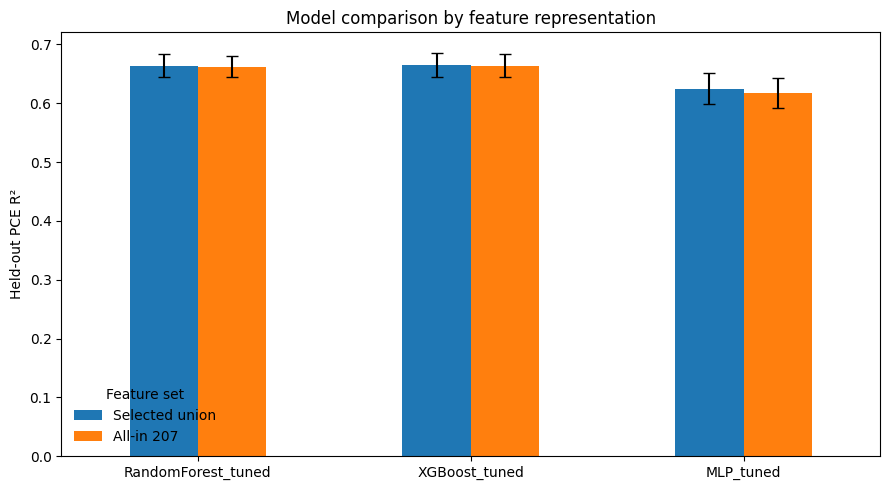

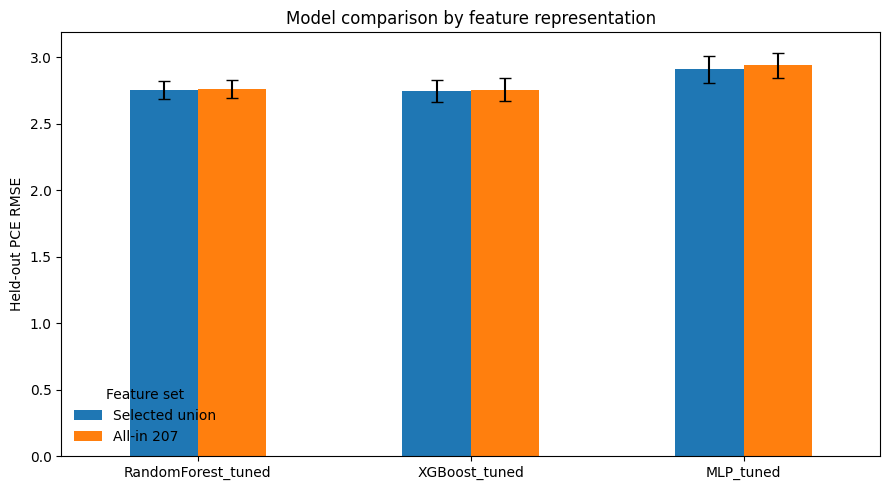

In [9]:
# ============================================================
# 8. Exploratory plots
# ============================================================

model_order = [
    "RandomForest_tuned",
    "XGBoost_tuned",
    "MLP_tuned",
]
feature_order = ["Selected union", "All-in 207"]

r2_plot = (
    MODEL_COMPARISON_SUMMARY
    .pivot(index="model", columns="feature_set", values="PCE_R2_mean")
    .reindex(index=model_order, columns=feature_order)
)
r2_error = (
    MODEL_COMPARISON_SUMMARY
    .pivot(index="model", columns="feature_set", values="PCE_R2_std")
    .reindex(index=model_order, columns=feature_order)
)

ax = r2_plot.plot(
    kind="bar",
    yerr=r2_error,
    capsize=4,
    figsize=(9, 5),
)
ax.set_ylabel("Held-out PCE R²")
ax.set_xlabel("")
ax.set_title("Model comparison by feature representation")
ax.legend(title="Feature set", frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

rmse_plot = (
    MODEL_COMPARISON_SUMMARY
    .pivot(index="model", columns="feature_set", values="PCE_RMSE_mean")
    .reindex(index=model_order, columns=feature_order)
)
rmse_error = (
    MODEL_COMPARISON_SUMMARY
    .pivot(index="model", columns="feature_set", values="PCE_RMSE_std")
    .reindex(index=model_order, columns=feature_order)
)

ax = rmse_plot.plot(
    kind="bar",
    yerr=rmse_error,
    capsize=4,
    figsize=(9, 5),
)
ax.set_ylabel("Held-out PCE RMSE")
ax.set_xlabel("")
ax.set_title("Model comparison by feature representation")
ax.legend(title="Feature set", frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## How to interpret this exploratory experiment

1. First compare **selected union vs all-in 207 within each model** using the paired deltas.
2. Then check whether the **model ranking changes** between feature representations.
3. Do not compare these results directly with the old selected-50 table: the selected representation has been redefined.
4. If both representations give nearly identical model ranking and performance, the thesis can keep the compact selected representation and treat all-in 207 as a robustness check.
5. If all-in materially improves XGBoost or MLP, or changes the model ranking, feature representation must be reported as part of the model-comparison conclusion.
6. The kernel notebook remains separate because its block structure must be rebuilt from the final frozen selected features.